# 定位结果数据分析与可视化

**数据输入**：
- `locations_‘DATA_SET’_mm_DD_HHMMSS.csv`：定位计算结果
- `ground_truths_train.csv`：地面实测基准数据

## 第1部分：初始化与加载

In [43]:
import os
from os.path import join, abspath
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import gaussian_kde
import scienceplots
from glob import glob
from datetime import date
import warnings
warnings.filterwarnings('ignore')

# 手动配置参数
SOL_METHOD = 'spp-test'  # 解算方法名称 (SPP, RTK, PPP, PPK等)
DATA_SET = 'test'  # 数据集名称 (train, test等)

DRAW_SET = 'picture'  # 绘制图片保存文件
REPO_SET = 'report'   # 分析报告保存文件
DATA_DIR = '../data/'  # 数据文件相对python脚本的路径
# 自动配置参数
DRAW_DIR = abspath(DATA_DIR + DRAW_SET) # 输出绘制图片路径
REPO_DIR = abspath(DATA_DIR + REPO_SET) # 输出分析报告路径
today_str = date.today().strftime("%Y%m%d")  # 当前日期

# 时间序列图配置 (设置为 None 则不绘制)
TIME_SERIES_TRIPS = ['2020-06-25-00-34-us-ca-mtv-sb-101']  # e.g., ['2023-09-06-18-47-us-ca'] 或 None 表示不绘制
TIME_SERIES_PHONES = None  # e.g., ['pixel5a', 'pixel6pro'] 或 None 表示全部机型

# 设置学术级绘图参数
size_font = 10

plt.style.use(['science', 'no-latex'])
plt.rcParams['font.family'] = ['Times New Roman', 'SimSun']  # 按顺序尝试，直到找到支持字符的字体  # 英文用 Arial，中文用宋体
plt.rcParams.update({
    'font.size': size_font,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'grid.color': 'gray',
    'grid.linewidth': 0.5,
    'axes.linewidth': 1.0,
})
# 定义绘图常用尺寸（mm），及对应英寸尺寸
fig_width_mm = [75, 90, 120, 150]
fig_height_mm = [60, 80, 100, 120]

# 将mm转换为英寸用于matplotlib
mm = 1 / 25.4
fig_width = [w * mm for w in fig_width_mm]
fig_height = [h * mm for h in fig_height_mm]

print('='*70)
print(f'{SOL_METHOD}定位结果分析系统')
print('='*70)
print(f'数据目录: {DATA_DIR}')
print(f'数据集: {DATA_SET}')
print(f'解算方法: {SOL_METHOD}')
print(f'分析日期: {date.today().strftime("%Y-%m-%d")}')

spp-test定位结果分析系统
数据目录: ../data/
数据集: test
解算方法: spp-test
分析日期: 2026-03-28


In [44]:
# 查找并加载最新的定位结果文件
# 文件名格式应为 locations_{SOL_METHOD}_{DATA_SET}_%m_%d_%H%M%S.csv
location_files = glob(join(DATA_DIR, f'locations_{SOL_METHOD}_{DATA_SET}_*.csv'))
if location_files:
    location_files = sorted(location_files, key=os.path.getmtime)  # 按修改时间排序，选择最新的
    location_file = location_files[-1]
else:
    # 如果没有符合DATA_SET的文件，则寻找所有locations_*.csv，再取最近一天（即最新修改时间的文件）
    all_location_files = glob(join(DATA_DIR, 'locations_*.csv'))
    if all_location_files:
        all_location_files = sorted(all_location_files, key=os.path.getmtime)
        location_file = all_location_files[-1]
    else:
        location_file = None

groundtruth_file = join(DATA_DIR, f'ground_truths_{DATA_SET}.csv')

print(f'\n文件检查:')
if location_file is not None:
    print(f'  定位结果: {os.path.basename(location_file)} - {"✓" if os.path.isfile(location_file) else "✗"}')
else:
    print(f'  定位结果: 未找到定位结果文件 ✗')

print(f'  地面真实: {os.path.basename(groundtruth_file)} - {"✓" if os.path.isfile(groundtruth_file) else "✗"}')

if (location_file is None or not os.path.isfile(location_file)) or not os.path.isfile(groundtruth_file):
    print('\n警告: 必要的输入文件不存在，请检查文件路径！')
else:
    print('\n✓ 所有输入文件已就绪')


文件检查:
  定位结果: locations_spp-test_test_03_28_185427.csv - ✓
  地面真实: ground_truths_test.csv - ✓

✓ 所有输入文件已就绪


In [45]:
# 加载定位结果数据
df_loc = pd.read_csv(location_file)
print(f'\n定位结果数据:')
print(f'  行数: {len(df_loc)}')
print(f'  列数: {len(df_loc.columns)}')
print(f'  列名: {list(df_loc.columns)}')
print(f'\n样本数据:')
print(df_loc.head(3))


定位结果数据:
  行数: 880
  列数: 13
  列名: ['tripId', 'UnixTimeMillis', 'LatitudeDegrees', 'LongitudeDegrees', 'Height', 'Quality', 'NumSatellites', 'Sde', 'Sdu', 'Sdn', 'Sdne', 'Sdeu', 'Sdun']

样本数据:
                             tripId  UnixTimeMillis  LatitudeDegrees  \
0  2020-12-10-22-52-us-ca-sjc-c/mi8   1607640781999        37.317870   
1  2020-12-10-22-52-us-ca-sjc-c/mi8   1607640783999        37.317923   
2  2020-12-10-22-52-us-ca-sjc-c/mi8   1607640784999        37.317911   

   LongitudeDegrees   Height  Quality  NumSatellites       Sde       Sdu  \
0       -121.948211  53.0994        5              5  247.1586  285.8528   
1       -121.948222  64.8131        5              4  400.3560  425.0575   
2       -121.948052  76.3767        5              5  247.1669  285.6381   

        Sdn      Sdne      Sdeu      Sdun  
0  640.4614 -147.0835 -283.2037  293.0205  
1  718.7632 -347.4388 -427.3899  434.2744  
2  640.5497 -146.8837 -282.7380  293.0754  


In [46]:
# 加载地面真实数据
df_truth = pd.read_csv(groundtruth_file)
print(f'\n地面真实数据:')
print(f'  行数: {len(df_truth)}')
print(f'  列数: {len(df_truth.columns)}')
print(f'  列名: {list(df_truth.columns)}')
print(f'\n样本数据:')
print(df_truth.head(3))


地面真实数据:
  行数: 1408
  列数: 5
  列名: ['tripId', 'UnixTimeMillis', 'LatitudeDegrees', 'LongitudeDegrees', ' Height']

样本数据:
                             tripId  UnixTimeMillis  LatitudeDegrees  \
0  2020-12-10-22-52-us-ca-sjc-c/mi8   1607640759999          37.3179   
1  2020-12-10-22-52-us-ca-sjc-c/mi8   1607640760999          37.3179   
2  2020-12-10-22-52-us-ca-sjc-c/mi8   1607640761999          37.3179   

   LongitudeDegrees    Height  
0       -121.948509  11.53334  
1       -121.948509  11.53334  
2       -121.948509  11.53334  


## 第2部分：数据预处理与合并

In [47]:
# 重命名列以便区分
loc_cols = ['tripId', 'UnixTimeMillis', 'Lat_calc', 'Lon_calc', 'Height_calc',
            'Quality', 'NumSatellites', 'Sde', 'Sdu', 'Sdn', 'Sdne', 'Sdeu', 'Sdun']
df_loc.columns = loc_cols[:len(df_loc.columns)]

df_truth_renamed = df_truth.copy()
df_truth_renamed.columns = [col.strip() for col in df_truth_renamed.columns]
df_truth_renamed.columns = ['tripId', 'UnixTimeMillis', 'Lat_truth', 'Lon_truth', 'Height_truth']

# 根据 tripId 和 UnixTimeMillis 合并
df_merged = pd.merge(df_loc, df_truth_renamed,
                     on=['tripId', 'UnixTimeMillis'],
                     how='inner')

print(f'数据合并完成:')
print(f'  定位数据行数: {len(df_loc)}')
print(f'  真实数据行数: {len(df_truth)}')
print(f'  合并后行数: {len(df_merged)}')
print(f'  匹配率: {100*len(df_merged)/max(len(df_loc), len(df_truth)):.1f}%')

数据合并完成:
  定位数据行数: 880
  真实数据行数: 1408
  合并后行数: 880
  匹配率: 62.5%


In [48]:
# 分类信息提取
df_merged['phone'] = df_merged['tripId'].apply(lambda x: x.split('/')[-1])
df_merged['dataset'] = df_merged['tripId'].apply(lambda x: '/'.join(x.split('/')[:-1]))

print(f'\n分类信息提取:')
print(f'  Dataset 数量: {df_merged["dataset"].nunique()}')
print(f'  Phone 设备数量: {df_merged["phone"].nunique()}')


分类信息提取:
  Dataset 数量: 1
  Phone 设备数量: 1


## 第3部分：坐标转换与误差计算

In [49]:
# 坐标转换：WGS84转ENU
# WGS84 常数
a = 6378137.0  # 长半轴 (m)
e2 = 0.081819189  # 第一偏心率平方

def lat_lon_to_enu(lat_ref, lon_ref, h_ref, lat, lon, h):
    """
    将WGS84经纬度坐标转换为ENU (East-North-Up) 坐标（差分）
    参考点: (lat_ref, lon_ref, h_ref)
    转换点: (lat, lon, h)
    返回: (E, N, U) 东北天方向距离 (m)
    """
    # 转换为弧度
    lat_rad = np.radians(lat)
    lon_rad = np.radians(lon)
    lat_ref_rad = np.radians(lat_ref)
    lon_ref_rad = np.radians(lon_ref)

    # 卯酉圆曲率半径
    N = a / np.sqrt(1 - e2 * np.sin(lat_ref_rad)**2)

    # 参考点 ECEF 坐标
    X_ref = (N + h_ref) * np.cos(lat_ref_rad) * np.cos(lon_ref_rad)
    Y_ref = (N + h_ref) * np.cos(lat_ref_rad) * np.sin(lon_ref_rad)
    Z_ref = (N * (1 - e2) + h_ref) * np.sin(lat_ref_rad)

    # 目标点 ECEF 坐标
    N_target = a / np.sqrt(1 - e2 * np.sin(lat_rad)**2)
    X = (N_target + h) * np.cos(lat_rad) * np.cos(lon_rad)
    Y = (N_target + h) * np.cos(lat_rad) * np.sin(lon_rad)
    Z = (N_target * (1 - e2) + h) * np.sin(lat_rad)

    # ECEF 差分
    dX, dY, dZ = X - X_ref, Y - Y_ref, Z - Z_ref

    # 旋转矩阵
    sin_lat = np.sin(lat_ref_rad)
    cos_lat = np.cos(lat_ref_rad)
    sin_lon = np.sin(lon_ref_rad)
    cos_lon = np.cos(lon_ref_rad)

    E = -sin_lon * dX + cos_lon * dY
    N = -sin_lat * cos_lon * dX - sin_lat * sin_lon * dY + cos_lat * dZ
    U = cos_lat * cos_lon * dX + cos_lat * sin_lon * dY + sin_lat * dZ

    return E, N, U

print('ENU坐标转换函数已定义')

ENU坐标转换函数已定义


In [50]:
# 计算 ENU 坐标
print('\n计算 ENU 坐标...')
df_merged[['err_e', 'err_n', 'err_u']] = df_merged.apply(
    lambda row: pd.Series(lat_lon_to_enu(
        row['Lat_truth'], row['Lon_truth'], row['Height_truth'],
        row['Lat_calc'], row['Lon_calc'], row['Height_calc']
    )),
    axis=1
)

print('✓ 完成\n')
print(f'ENU 误差范围:')
print(f'  East (E):  {df_merged["err_e"].min():>8.3f} ~ {df_merged["err_e"].max():>8.3f} m')
print(f'  North (N): {df_merged["err_n"].min():>8.3f} ~ {df_merged["err_n"].max():>8.3f} m')
print(f'  Up (U):    {df_merged["err_u"].min():>8.3f} ~ {df_merged["err_u"].max():>8.3f} m')


计算 ENU 坐标...
✓ 完成

ENU 误差范围:
  East (E):   -60.756 ~   52.811 m
  North (N):  -27.494 ~   37.232 m
  Up (U):     -60.444 ~   87.708 m


In [51]:
# 计算水平、垂直和总误差
df_merged['err_h'] = np.sqrt(df_merged['err_e']**2 + df_merged['err_n']**2)
# err_u 已经是ENU转换的U分量
df_merged['err_3d'] = np.sqrt(df_merged['err_e']**2 + df_merged['err_n']**2 + df_merged['err_u']**2)

print(f'\n综合误差统计:')
print(f'  水平误差 (E-N):  min={df_merged["err_h"].min():.3f}m, max={df_merged["err_h"].max():.3f}m, 均值={df_merged["err_h"].mean():.3f}m')
print(f'  垂直误差 (U):    min={df_merged["err_u"].min():.3f}m, max={df_merged["err_u"].max():.3f}m, 均值={df_merged["err_u"].mean():.3f}m')
print(f'  3D 总误差:      min={df_merged["err_3d"].min():.3f}m, max={df_merged["err_3d"].max():.3f}m, 均值={df_merged["err_3d"].mean():.3f}m')


综合误差统计:
  水平误差 (E-N):  min=0.093m, max=62.407m, 均值=11.446m
  垂直误差 (U):    min=-60.444m, max=87.708m, 均值=6.988m
  3D 总误差:      min=0.599m, max=95.442m, 均值=21.284m


## 第4部分：时间序列分析（选择性分析）

In [52]:
# 时间序列分析
if TIME_SERIES_TRIPS is not None or TIME_SERIES_PHONES is not None:
    print(f'绘制时间序列图...')
    
    df_ts = df_merged.copy()
    
    if TIME_SERIES_TRIPS is not None:
        if isinstance(TIME_SERIES_TRIPS, str):
            TIME_SERIES_TRIPS = [TIME_SERIES_TRIPS]
        df_ts = df_ts[df_ts['dataset'].isin(TIME_SERIES_TRIPS)]
    
    if TIME_SERIES_PHONES is not None:
        if isinstance(TIME_SERIES_PHONES, str):
            TIME_SERIES_PHONES = [TIME_SERIES_PHONES]
        df_ts = df_ts[df_ts['phone'].isin(TIME_SERIES_PHONES)]
    
    if len(df_ts) == 0:
        print('  警告: 没有符合条件的数据')
    else:
        df_ts['time_sec'] = (df_ts['UnixTimeMillis'] - df_ts['UnixTimeMillis'].min()) / 1000 # 相对时间：从第一条数据开始经过的秒数
        
        for trip_id in df_ts['tripId'].unique():
            df_trip = df_ts[df_ts['tripId'] == trip_id]
            trip_name = trip_id.replace('/', '_').replace(':', '-')
            
            legend_labels = { # 设置图例文字内容
                'err_e': '东向',      # 东向误差
                'err_n': '北向',      # 北向误差
                'err_u': '高度',      # 高度误差
                'err_h': '水平',      # 水平误差
                'NumSatellites': '可见卫星数' # 可见卫星数
            }
            #设置图片大小
            fig, axes = plt.subplots(2, 1, figsize=(fig_width[2], fig_height[1]), sharex=True)

            ax1 = axes[0]
            line_e, = ax1.plot(df_trip['time_sec'], df_trip['err_e'], 'b-', label=legend_labels.get('err_e', 'East'), alpha=0.7)
            line_n, = ax1.plot(df_trip['time_sec'], df_trip['err_n'], 'g-', label=legend_labels.get('err_n', 'North'), alpha=0.7)
            line_u, = ax1.plot(df_trip['time_sec'], df_trip['err_u'], 'r-', label=legend_labels.get('err_u', 'Up'), alpha=0.7)
            line_h, = ax1.plot(df_trip['time_sec'], df_trip['err_h'], 'k-', label=legend_labels.get('err_h', 'Horizontal'), alpha=0.7, linewidth=2)
            ax1.set_ylabel('真实误差 (m)')
            
            ax1.set_ylim(-30, 30)
            handles = [line_e, line_n, line_u, line_h]
            labels = [h.get_label() for h in handles]
            ax1.legend(handles, labels,
                loc='upper right',    # 图例位置，upper上lower下center中
                framealpha=0.8,       # 透明度，默认1.0
                ncol=4,               # 横向n列，默认1
                frameon=True,         # 显示边框，默认True
                edgecolor='k',        # 边框黑色，默认灰色
                labelspacing=0.1,     # 行间距，默认0.5                
                columnspacing=0.8,    # 列间距，默认2.0
                handlelength=1.5,     # 句柄长度，默认2.0
                handletextpad=0.1,    # 句柄与文字间距,默认0.8
                borderpad=0.3         # 边框与内容之间的内边距，默认0.4
            )
            ax1.set_title(f'{trip_id} - 定位精度')
            ax1.grid(True, alpha=0.3)

            hline1 = ax1.axhline(y=1, color='orange', linestyle='--', alpha=0.5)
            hline2 = ax1.axhline(y=3, color='red', linestyle='--', alpha=0.5)
            ax1.text(df_trip['time_sec'].min(), 1, '1m', color='orange', va='bottom', ha='left')
            ax1.text(df_trip['time_sec'].min(), 3, '3m', color='red', va='bottom', ha='left')

            ax2 = axes[1]
            line_sat, = ax2.plot(df_trip['time_sec'], df_trip['NumSatellites'], 'b-', label=legend_labels.get('NumSatellites', 'Satellites'), alpha=0.7)
            ax2.set_ylabel('卫星数量')
            ax2.set_xlabel('相对时间(秒)')
            ax2.legend([line_sat], [line_sat.get_label()], 
                loc='lower left', 
                framealpha=0.8,
                frameon=True,
                edgecolor='k',              
                handlelength=1.5,
                handletextpad=0.1,
                borderpad=0.3
                    )
            ax2.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.savefig(join(DRAW_DIR, f'00_time_series_{SOL_METHOD}_{trip_name}_{today_str}.png'), dpi=300, bbox_inches='tight')
            plt.show()
    
    print(f'时间序列图绘制完成\n')
else:
    print('时间序列图已跳过（TIME_SERIES_TRIPS 未配置）\n')

绘制时间序列图...
  警告: 没有符合条件的数据
时间序列图绘制完成



## 第5部分：全局统计分析

In [53]:
# 全局统计分析
print(f'\n全局统计（所有数据）:')
print('='*80)

h_error = df_merged['err_h']
e_error = df_merged['err_e']
n_error = df_merged['err_n']
u_error = df_merged['err_u']

print(f'水平误差 (East-North 平面):')
print(f'  RMS:       {np.sqrt(np.mean(h_error**2)):>10.4f} m')
print(f'  Mean:      {h_error.mean():>10.4f} m')
print(f'  Median:    {h_error.median():>10.4f} m')
print(f'  Std Dev:   {h_error.std():>10.4f} m')
print(f'  P68:       {np.percentile(h_error, 68):>10.4f} m')
print(f'  P95:       {np.percentile(h_error, 95):>10.4f} m')
print(f'  Min:       {h_error.min():>10.4f} m')
print(f'  Max:       {h_error.max():>10.4f} m')
print(f'  精度 (≤1m):  {100*np.sum(h_error<=1)/len(h_error):>6.2f}%')
print(f'  精度 (≤1.5m):{100*np.sum(h_error<=1.5)/len(h_error):>6.2f}%')
print(f'  精度 (≤3m):  {100*np.sum(h_error<=3)/len(h_error):>6.2f}%')

print(f'\nEast (E) 方向:')
print(f'  RMS:   {np.sqrt(np.mean(e_error**2)):>10.4f} m')
print(f'  Mean:  {e_error.mean():>10.4f} m')
print(f'  P68:   {np.percentile(np.abs(e_error), 68):>10.4f} m')
print(f'  P95:   {np.percentile(np.abs(e_error), 95):>10.4f} m')

print(f'\nNorth (N) 方向:')
print(f'  RMS:   {np.sqrt(np.mean(n_error**2)):>10.4f} m')
print(f'  Mean:  {n_error.mean():>10.4f} m')
print(f'  P68:   {np.percentile(np.abs(n_error), 68):>10.4f} m')
print(f'  P95:   {np.percentile(np.abs(n_error), 95):>10.4f} m')

print(f'\nUp (U) 方向:')
print(f'  RMS:   {np.sqrt(np.mean(u_error**2)):>10.4f} m')
print(f'  Mean:  {u_error.mean():>10.4f} m')
print(f'  P68:   {np.percentile(np.abs(u_error), 68):>10.4f} m')
print(f'  P95:   {np.percentile(np.abs(u_error), 95):>10.4f} m')


全局统计（所有数据）:
水平误差 (East-North 平面):
  RMS:          13.9769 m
  Mean:         11.4459 m
  Median:        9.5842 m
  Std Dev:       8.0260 m
  P68:          13.0560 m
  P95:          25.4330 m
  Min:           0.0927 m
  Max:          62.4071 m
  精度 (≤1m):    0.80%
  精度 (≤1.5m):  1.48%
  精度 (≤3m):    5.68%

East (E) 方向:
  RMS:      11.2582 m
  Mean:     -3.4083 m
  P68:       9.4055 m
  P95:      22.2433 m

North (N) 方向:
  RMS:       8.2829 m
  Mean:      3.0532 m
  P68:       7.4891 m
  P95:      16.7469 m

Up (U) 方向:
  RMS:      21.5174 m
  Mean:      6.9877 m
  P68:      19.4867 m
  P95:      45.6685 m


## 第6部分：分组统计分析

In [54]:
# 定义误差指标计算函数，同时统计U方向、3D方向的各种指标
def calculate_statistics(df_group):
    results = {}
    
    err_e = df_group['err_e'].values
    err_n = df_group['err_n'].values
    err_u = df_group['err_u'].values
    err_h = df_group['err_h'].values
    err_3d = df_group['err_3d'].values

    # 1. RMS
    results['RMS_E']   = np.sqrt(np.mean(err_e**2))
    results['RMS_N']   = np.sqrt(np.mean(err_n**2))
    results['RMS_U']   = np.sqrt(np.mean(err_u**2))
    results['RMS_H']   = np.sqrt(np.mean(err_h**2))
    results['RMS_3D']  = np.sqrt(np.mean(err_3d**2))

    # 2. P68
    results['P68_E']   = np.percentile(np.abs(err_e), 68)
    results['P68_N']   = np.percentile(np.abs(err_n), 68)
    results['P68_U']   = np.percentile(np.abs(err_u), 68)
    results['P68_H']   = np.percentile(err_h, 68)
    results['P68_3D']  = np.percentile(err_3d, 68)

    # 3. P95
    results['P95_E']   = np.percentile(np.abs(err_e), 95)
    results['P95_N']   = np.percentile(np.abs(err_n), 95)
    results['P95_U']   = np.percentile(np.abs(err_u), 95)
    results['P95_H']   = np.percentile(err_h, 95)
    results['P95_3D']  = np.percentile(err_3d, 95)

    # 4. RMS within 68th/95th percentile for 水平、U、3D方向
    mask_68_h = err_h <= results['P68_H']
    mask_95_h = err_h <= results['P95_H']
    mask_68_u = np.abs(err_u) <= results['P68_U']
    mask_95_u = np.abs(err_u) <= results['P95_U']
    mask_68_3d = err_3d <= results['P68_3D']
    mask_95_3d = err_3d <= results['P95_3D']

    results['RMS.68_H'] = np.sqrt(np.mean(err_h[mask_68_h]**2)) if mask_68_h.sum() > 0 else np.nan
    results['RMS.95_H'] = np.sqrt(np.mean(err_h[mask_95_h]**2)) if mask_95_h.sum() > 0 else np.nan

    results['RMS.68_U'] = np.sqrt(np.mean(err_u[mask_68_u]**2)) if mask_68_u.sum() > 0 else np.nan
    results['RMS.95_U'] = np.sqrt(np.mean(err_u[mask_95_u]**2)) if mask_95_u.sum() > 0 else np.nan

    results['RMS.68_3D'] = np.sqrt(np.mean(err_3d[mask_68_3d]**2)) if mask_68_3d.sum() > 0 else np.nan
    results['RMS.95_3D'] = np.sqrt(np.mean(err_3d[mask_95_3d]**2)) if mask_95_3d.sum() > 0 else np.nan

    # 5. “精度”覆盖统计, 水平/U/3D方向在1m,1.5m,3m以内的比例
    results['Within_1m_H']   = 100 * np.sum(err_h <= 1) / len(err_h)
    results['Within_1.5m_H'] = 100 * np.sum(err_h <= 1.5) / len(err_h)
    results['Within_3m_H']   = 100 * np.sum(err_h <= 3) / len(err_h)

    results['Within_1m_U']   = 100 * np.sum(np.abs(err_u) <= 1) / len(err_u)
    results['Within_1.5m_U'] = 100 * np.sum(np.abs(err_u) <= 1.5) / len(err_u)
    results['Within_3m_U']   = 100 * np.sum(np.abs(err_u) <= 3) / len(err_u)

    results['Within_1m_3D']   = 100 * np.sum(err_3d <= 1) / len(err_3d)
    results['Within_1.5m_3D'] = 100 * np.sum(err_3d <= 1.5) / len(err_3d)
    results['Within_3m_3D']   = 100 * np.sum(err_3d <= 3) / len(err_3d)

    results['Count'] = len(df_group)
    return results

print('误差指标计算函数已定义')

误差指标计算函数已定义


### 6.1 Dateset 

In [55]:
# 按 Dataset 分组统计
print(f'按 Dataset 分组统计')
print('='*80)

dataset_stats = []
for dataset in sorted(df_merged['dataset'].unique()):
    dataset_df = df_merged[df_merged['dataset'] == dataset] # 获取当前数据集的所有数据（完整 DataFrame）

    stats = calculate_statistics(dataset_df) # 调用函数计算详细统计量
    stats['Dataset'] = dataset
    dataset_stats.append(stats)

df_dataset_stats = pd.DataFrame(dataset_stats)

cols_order = [
    'Dataset', 'Count', 
    # RMS
    'RMS_H', 'RMS_U', 'RMS_3D',
    # P68
    'P68_H', 'P68_U', 'P68_3D',
    # P95
    'P95_H', 'P95_U', 'P95_3D',
    # RMS within %
    'RMS.68_H', 'RMS.68_U', 'RMS.68_3D',
    'RMS.95_H', 'RMS.95_U', 'RMS.95_3D',
    # within 1m 1.5m 3m
    'Within_1m_H', 'Within_1m_U', 'Within_1m_3D',
    'Within_1.5m_H', 'Within_1.5m_U', 'Within_1.5m_3D',
    'Within_3m_H', 'Within_3m_U', 'Within_3m_3D',
]

# 过滤只保留有的数据列（防御下游数据结构变化）
cols_order = [col for col in cols_order if col in df_dataset_stats.columns]
df_dataset_stats = df_dataset_stats[cols_order]

print(f'按Dataset统计结果 (全部方向误差):\n')
print(df_dataset_stats.to_string(index=False))

按 Dataset 分组统计
按Dataset统计结果 (全部方向误差):

                     Dataset  Count     RMS_H     RMS_U    RMS_3D     P68_H     P68_U    P68_3D     P95_H     P95_U    P95_3D  RMS.68_H  RMS.68_U  RMS.68_3D  RMS.95_H  RMS.95_U  RMS.95_3D  Within_1m_H  Within_1m_U  Within_1m_3D  Within_1.5m_H  Within_1.5m_U  Within_1.5m_3D  Within_3m_H  Within_3m_U  Within_3m_3D
2020-12-10-22-52-us-ca-sjc-c    880 13.976875 21.517419 25.658378 13.055995 19.486671 24.118225 25.433009 45.668454 50.864895  7.914194  9.880287  14.468709 11.592638 17.975493  22.127504     0.795455     4.090909      0.113636       1.477273       6.590909        0.227273     5.681818    13.409091      1.022727


### 6.2 Phone

In [56]:
# 按 Phone 设备分组统计
print(f'按 Phone 设备分组统计')
print('='*80)

phone_stats = []
for phone in sorted(df_merged['phone'].unique()):
    phone_df = df_merged[df_merged['phone'] == phone]  # 获取当前Phone的所有数据（完整 DataFrame）
    stats = calculate_statistics(phone_df)  # 调用函数计算详细统计量
    stats['Phone'] = phone
    phone_stats.append(stats)

df_phone_stats = pd.DataFrame(phone_stats)

# 需要统计水平方向（H）、垂直方向（U）、三维（3D）的各误差指标
cols_order = [
    'Phone', 'Count',
    # RMS
    'RMS_H', 'RMS_U', 'RMS_3D',
    # P68
    'P68_H', 'P68_U', 'P68_3D',
    # P95
    'P95_H', 'P95_U', 'P95_3D',
    # RMS.68
    'RMS.68_H', 'RMS.68_U', 'RMS.68_3D',
    # RMS.95
    'RMS.95_H', 'RMS.95_U', 'RMS.95_3D',
    # within 1m, 1.5m, 3m (分别按H, U, 3D)
    'Within_1m_H', 'Within_1m_U', 'Within_1m_3D',
    'Within_1.5m_H', 'Within_1.5m_U', 'Within_1.5m_3D',
    'Within_3m_H', 'Within_3m_U', 'Within_3m_3D',
]

# 过滤只保留有的数据列（兼容不同calculate_statistics返回值）
cols_order = [col for col in cols_order if col in df_phone_stats.columns]
df_phone_stats = df_phone_stats[cols_order]

print(f'按Phone统计结果 (全部方向误差):\n')
print(df_phone_stats.to_string(index=False))

按 Phone 设备分组统计
按Phone统计结果 (全部方向误差):

Phone  Count     RMS_H     RMS_U    RMS_3D     P68_H     P68_U    P68_3D     P95_H     P95_U    P95_3D  RMS.68_H  RMS.68_U  RMS.68_3D  RMS.95_H  RMS.95_U  RMS.95_3D  Within_1m_H  Within_1m_U  Within_1m_3D  Within_1.5m_H  Within_1.5m_U  Within_1.5m_3D  Within_3m_H  Within_3m_U  Within_3m_3D
  mi8    880 13.976875 21.517419 25.658378 13.055995 19.486671 24.118225 25.433009 45.668454 50.864895  7.914194  9.880287  14.468709 11.592638 17.975493  22.127504     0.795455     4.090909      0.113636       1.477273       6.590909        0.227273     5.681818    13.409091      1.022727


### 6.3 Dataset X Phone (数据文件)

In [57]:
# 按数据文件为单位的统计分析
print(f'按数据文件统计分析...')
print('='*80)

file_stats = []
for trip_id in df_merged['tripId'].unique():
    df_file = df_merged[df_merged['tripId'] == trip_id]
    phone = trip_id.split('/')[-1]
    dataset = '/'.join(trip_id.split('/')[:-1])
    
    stats = calculate_statistics(df_file)
    stats['tripId'] = trip_id
    stats['phone'] = phone
    stats['dataset'] = dataset
    file_stats.append(stats)

df_file_stats = pd.DataFrame(file_stats)

# 同时统计 H、U、3D 三个方向的指标
cols_order = [
    'tripId', 'dataset', 'phone', 'Count', 
    # RMS
    'RMS_H', 'RMS_U', 'RMS_3D',
    # P68
    'P68_H', 'P68_U', 'P68_3D',
    # P95
    'P95_H', 'P95_U', 'P95_3D',
    # RMS.68
    'RMS.68_H', 'RMS.68_U', 'RMS.68_3D',
    # RMS.95
    'RMS.95_H', 'RMS.95_U', 'RMS.95_3D',
    # within 1m, 1.5m, 3m (分别按H, U, 3D)
    'Within_1m_H', 'Within_1m_U', 'Within_1m_3D',
    'Within_1.5m_H', 'Within_1.5m_U', 'Within_1.5m_3D',
    'Within_3m_H', 'Within_3m_U', 'Within_3m_3D',
]

# 过滤只保留有的数据列（兼容不同calculate_statistics返回值）
cols_order = [col for col in cols_order if col in df_file_stats.columns]
df_file_stats = df_file_stats[cols_order]

print(f'按文件统计结果 (各方向误差):\n')
print(df_file_stats.to_string(index=False))

file_stats_csv = f'{SOL_METHOD}_statistics_{DATA_SET}_{today_str}.csv'
df_file_stats.to_csv(join(REPO_DIR, file_stats_csv), index=False)
print(f'\n文件统计已保存: {file_stats_csv}')

按数据文件统计分析...
按文件统计结果 (各方向误差):

                          tripId                      dataset phone  Count     RMS_H     RMS_U    RMS_3D     P68_H     P68_U    P68_3D     P95_H     P95_U    P95_3D  RMS.68_H  RMS.68_U  RMS.68_3D  RMS.95_H  RMS.95_U  RMS.95_3D  Within_1m_H  Within_1m_U  Within_1m_3D  Within_1.5m_H  Within_1.5m_U  Within_1.5m_3D  Within_3m_H  Within_3m_U  Within_3m_3D
2020-12-10-22-52-us-ca-sjc-c/mi8 2020-12-10-22-52-us-ca-sjc-c   mi8    880 13.976875 21.517419 25.658378 13.055995 19.486671 24.118225 25.433009 45.668454 50.864895  7.914194  9.880287  14.468709 11.592638 17.975493  22.127504     0.795455     4.090909      0.113636       1.477273       6.590909        0.227273     5.681818    13.409091      1.022727

文件统计已保存: spp-test_statistics_test_20260328.csv


## 第7部分：可视化图表

### 7.1 CDF 水平垂直误差

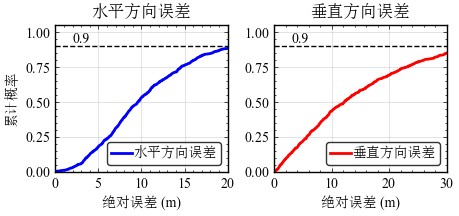

已保存: 01_cdf_spp-test_test_20260328.png


In [58]:
# 绘制水平和垂直方向的cdf图
fig, axes = plt.subplots(1, 2, figsize=(fig_width[2], fig_height[0]))

def plot_cdf_subplot(ax, error_data, label, color, x_max=None, show_ylabel=True):
    sorted_data = np.sort(error_data)
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax.plot(sorted_data, cdf, color=color, linewidth=2, label=label)
    ax.set_xlabel('绝对误差 (m)')
    if show_ylabel:
        ax.set_ylabel('累计概率')
    ax.set_title(f'{label}')
    ax.grid(True, alpha=0.3)
    ax.legend(
        framealpha=0.8,       # 透明度，默认1.0
        frameon=True,         # 显示边框，默认True
        edgecolor='k',        # 边框黑色，默认灰色
        handlelength=1.5,     # 句柄长度，默认2.0
        handletextpad=0.1,    # 句柄与文字间距,默认0.8
        borderpad=0.3         # 边框与内容之间的内边距，默认0.4
    )
    ax.set_ylim(0, 1.05)
    ax.set_xlim(0, x_max)
    ax.axhline(0.9, color='black', linestyle='--', linewidth=1)
    ax.text(ax.get_xlim()[1]*0.2, 0.9, '0.9', va='bottom', ha='right', color='black')

# 可以根据需求手动设置x轴量程x_max
x_max_h = 20
x_max_u = 30

plot_cdf_subplot(axes[0], h_error, '水平方向误差', 'blue', x_max_h, show_ylabel=True)
plot_cdf_subplot(axes[1], np.abs(u_error), '垂直方向误差', 'red', x_max_u, show_ylabel=False)

plt.tight_layout()
plt.savefig(join(DRAW_DIR, f'02_cdf_{SOL_METHOD}_{DATA_SET}_{today_str}.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f'已保存: 01_cdf_{SOL_METHOD}_{DATA_SET}_{today_str}.png')

### 7.2 热力图 Dataset x Phone

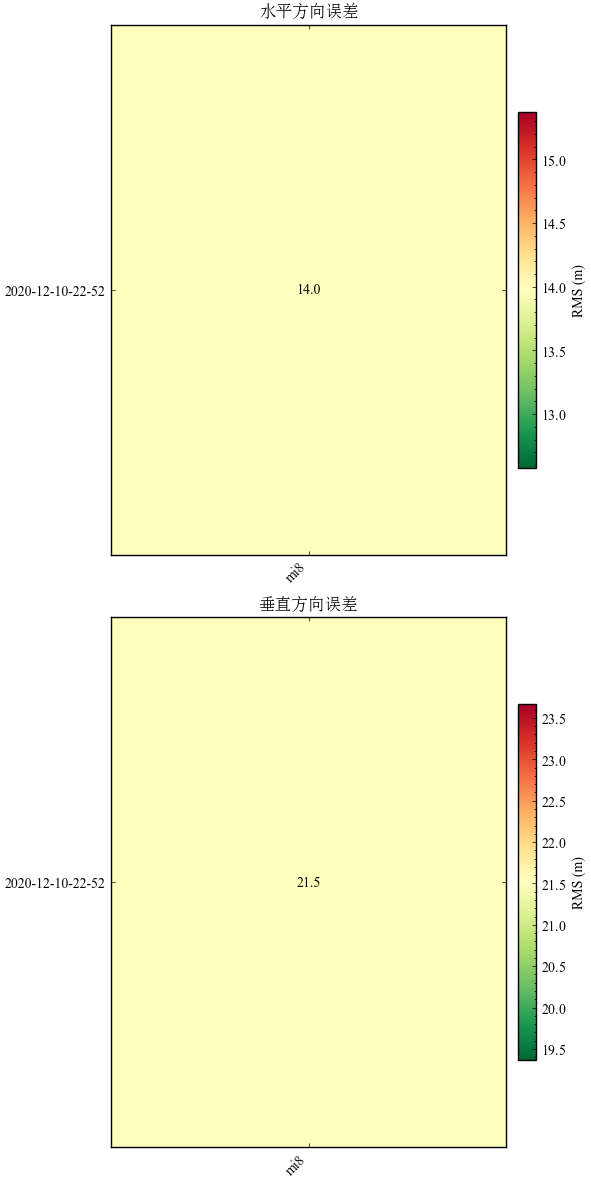

已保存: 02_heatmap_spp-test_test_20260328.png


In [59]:
# Dataset x Phone RMS h、u热力图在一个2x1子图中绘制
pivot_rms_h = df_merged.groupby(['dataset', 'phone']).apply(
    lambda x: np.sqrt(np.mean(x['err_h']**2))
).unstack()
pivot_rms_u = df_merged.groupby(['dataset', 'phone']).apply(
    lambda x: np.sqrt(np.mean(x['err_u']**2))
).unstack()

fig, axes = plt.subplots(2, 1, figsize=(fig_width[3], 300 * mm), constrained_layout=True)

for idx, (pivot, title) in enumerate(zip(
    [pivot_rms_h, pivot_rms_u], 
    ['水平方向误差', '垂直方向误差']
)):
    im = axes[idx].imshow(pivot.values, cmap='RdYlGn_r', aspect='auto')
    axes[idx].set_xticks(np.arange(len(pivot.columns)))
    axes[idx].set_yticks(np.arange(len(pivot.index)))
    axes[idx].set_xticklabels(pivot.columns, rotation=45, ha='right')
    axes[idx].set_yticklabels([str(idx)[:16] for idx in pivot.index]) # y标签为前16位
    # 添加数值标签
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.iloc[i, j]
            if not np.isnan(val):
                axes[idx].text(j, i, f'{val:.1f}', ha='center', va='center')
    cbar = plt.colorbar(im, ax=axes[idx], fraction=0.045, pad=0.03)
    cbar.set_label('RMS (m)')
    axes[idx].set_title(title)

    # 绘制热力图的网格线
    axes[idx].set_xticks(np.arange(-.5, len(pivot.columns), 1), minor=True)
    axes[idx].set_yticks(np.arange(-.5, len(pivot.index), 1), minor=True)
    axes[idx].grid(which="minor", color='k', linestyle='-', linewidth=0.5, alpha=0.2)
    axes[idx].tick_params(which="minor", bottom=False, left=False)

plt.savefig(join(DRAW_DIR, f'02_heatmap_{SOL_METHOD}_{DATA_SET}_{today_str}.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f'已保存: 02_heatmap_{SOL_METHOD}_{DATA_SET}_{today_str}.png')

### 7.3 直方图 水平垂直误差分布

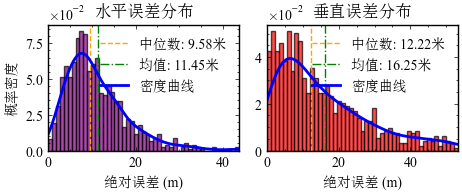

已保存: 03_histogram_spp-test_test_20260328.png


In [60]:
# ENU误差分布直方图
fig, axes = plt.subplots(1, 2, figsize=(fig_width[2], fig_height[0]))
# 限制X轴范围，避免直方图过扁
h_xmax = np.percentile(h_error, 99)  # 取99分位数
u_xmax = np.percentile(np.abs(u_error), 98) # 取98分位数
h_bins = np.linspace(0, h_xmax, 50)
u_bins = np.linspace(0, u_xmax, 50)

# 水平误差
n_h, bins_h, patches_h = axes[0].hist(h_error, bins=h_bins, color='purple', alpha=0.7, edgecolor='black', density=True)
axes[0].set_title('水平误差分布')
axes[0].set_xlabel('绝对误差 (m)')
axes[0].set_ylabel('概率密度')
# 计算中位数和均值
h_median = np.median(h_error)
h_mean = np.mean(h_error)
# 中位数和平均数的参考线
axes[0].axvline(h_median, color='orange', linestyle='--', label=f'中位数: {h_median:.2f}米')
axes[0].axvline(h_mean, color='green', linestyle='-.', label=f'均值: {h_mean:.2f}米')
# 拟合并绘制概率密度曲线
kde_h = gaussian_kde(h_error)
x_h = np.linspace(0, h_xmax, 500)
axes[0].plot(x_h, kde_h(x_h), color='blue', lw=2, label='密度曲线')

axes[0].legend()
axes[0].set_xlim(0, h_xmax)
axes[0].yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
axes[0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))

# 垂直误差
n_u, bins_u, patches_u = axes[1].hist(np.abs(u_error), bins=u_bins, color='red', alpha=0.7, edgecolor='black', density=True)
axes[1].set_title('垂直误差分布')
axes[1].set_xlabel('绝对误差 (m)')
# 计算中位数和均值
u_median = np.median(np.abs(u_error))
u_mean = np.mean(np.abs(u_error))
# 中位数和平均数的参考线
axes[1].axvline(u_median, color='orange', linestyle='--', label=f'中位数: {u_median:.2f}米')
axes[1].axvline(u_mean, color='green', linestyle='-.', label=f'均值: {u_mean:.2f}米')
# 拟合并绘制概率密度曲线
kde_u = gaussian_kde(np.abs(u_error))
x_u = np.linspace(0, u_xmax, 500)
axes[1].plot(x_u, kde_u(x_u), color='blue', lw=2, label='密度曲线')

axes[1].legend()
axes[1].set_xlim(0, u_xmax)
axes[1].yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
axes[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))

plt.tight_layout()
plt.savefig(join(DRAW_DIR, f'03_histogram_{SOL_METHOD}_{DATA_SET}_{today_str}.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f'已保存: 03_histogram_{SOL_METHOD}_{DATA_SET}_{today_str}.png')

### 7.4 箱线图 Phone

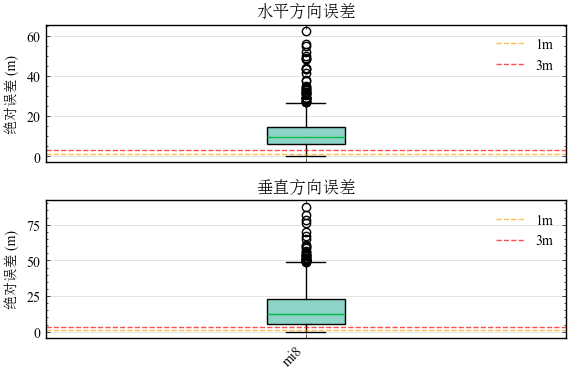

已保存: 04_boxplot_spp-test_test_20260328.png


In [61]:
# 按Phone的箱线图（水平+垂直，2行1列）
fig, axes = plt.subplots(2, 1, figsize=(fig_width[3], fig_height[2]))

phone_labels = df_merged['phone'].unique()
phone_h_data = [df_merged[df_merged['phone'] == p]['err_h'].values for p in phone_labels]
phone_v_data = [np.abs(df_merged[df_merged['phone'] == p]['err_u'].values) for p in phone_labels]

colors = plt.cm.Set3(np.linspace(0, 1, len(phone_labels)))

# 水平误差箱线图
bp_h = axes[0].boxplot(phone_h_data, labels=['']*len(phone_labels), patch_artist=True) # 不设置标签
for patch, color in zip(bp_h['boxes'], colors):
    patch.set_facecolor(color)
axes[0].set_ylabel('绝对误差 (m)')
axes[0].set_title('水平方向误差')
axes[0].axhline(y=1, color='orange', linestyle='--', alpha=0.7, label='1m')
axes[0].axhline(y=3, color='red', linestyle='--', alpha=0.7, label='3m')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# 垂直误差箱线图
bp_v = axes[1].boxplot(phone_v_data, labels=phone_labels, patch_artist=True)
for patch, color in zip(bp_v['boxes'], colors):
    patch.set_facecolor(color)
axes[1].set_ylabel('绝对误差 (m)')
axes[1].set_title('垂直方向误差')
axes[1].axhline(y=1, color='orange', linestyle='--', alpha=0.7, label='1m')
axes[1].axhline(y=3, color='red', linestyle='--', alpha=0.7, label='3m')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(join(DRAW_DIR, f'04_boxplot_{SOL_METHOD}_{DATA_SET}_{today_str}.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f'已保存: 04_boxplot_{SOL_METHOD}_{DATA_SET}_{today_str}.png')

### 7.5 柱状图 Phone

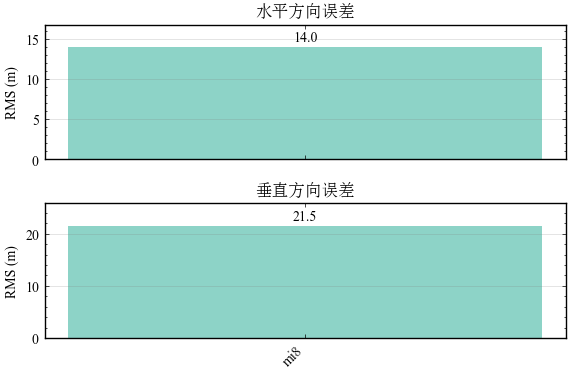

已保存: 05_bar_spp-test_test_20260328.png


In [62]:
# 按Phone的水平和高程RMS柱状图（2行1列）

# 为了确保 x 轴标签和数据顺序一致，建议直接用 groupby 结果的 index 作为 phone_labels
rms_h = df_merged.groupby('phone')['err_h'].apply(lambda x: np.sqrt(np.mean(x**2)))
rms_v = df_merged.groupby('phone')['err_u'].apply(lambda x: np.sqrt(np.mean(x**2)))

# 保证排序一致
phone_labels = rms_h.index.tolist()
colors_bar = plt.cm.Set3(np.linspace(0, 1, len(phone_labels)))

fig, axes = plt.subplots(2, 1, figsize=(fig_width[3], fig_height[2]), sharex=True)

# 水平方向RMS柱状图
bars_h = axes[0].bar(range(len(phone_labels)), rms_h.values, color=colors_bar)
axes[0].set_ylabel('RMS (m)')
axes[0].set_title('水平方向误差')
axes[0].grid(True, alpha=0.3, axis='y')

# 动态上边界
ymax_h = rms_h.max() * 1.2
axes[0].set_ylim(0, ymax_h)

for bar, val in zip(bars_h, rms_h.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, 
        min(bar.get_height() + 0.02 * ymax_h, ymax_h - 0.05 * ymax_h),
        f'{val:.1f}', ha='center', va='bottom',
    )

# 垂直方向RMS柱状图
bars_v = axes[1].bar(range(len(phone_labels)), rms_v.values, color=colors_bar)
axes[1].set_ylabel('RMS (m)')
axes[1].set_title('垂直方向误差')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_xticks(range(len(phone_labels)))
axes[1].set_xticklabels(phone_labels, rotation=45, ha='right')

ymax_v = rms_v.max() * 1.2
axes[1].set_ylim(0, ymax_v)

for bar, val in zip(bars_v, rms_v.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, 
        min(bar.get_height() + 0.02 * ymax_v, ymax_v - 0.05 * ymax_v),
        f'{val:.1f}', ha='center', va='bottom',
    )

plt.tight_layout()
plt.savefig(join(DRAW_DIR, f'05_bar_{SOL_METHOD}_{DATA_SET}_{today_str}.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f'已保存: 05_bar_{SOL_METHOD}_{DATA_SET}_{today_str}.png')

## 第8部分：生成分析报告

In [63]:
# 生成综合分析报告
report_file = join(REPO_DIR, f'{SOL_METHOD}_report_{DATA_SET}_{today_str}.txt')

with open(report_file, 'w', encoding='utf-8') as f:
    f.write('\n')
    f.write('='*80 + '\n')
    f.write(' ' * 20 + f'{SOL_METHOD} 定位结果分析报告\n')
    f.write('='*80 + '\n\n')
    
    f.write(f'分析日期: {date.today().strftime("%Y-%m-%d")}\n')
    f.write(f'数据集类型: {DATA_SET}\n')
    f.write(f'样本总数: {len(df_merged):,}\n')
    f.write(f'Dataset 数量: {df_merged["dataset"].nunique()}\n')
    f.write(f'Phone 设备数量: {df_merged["phone"].nunique()}\n\n')
    
    f.write('='*80 + '\n')
    f.write('1. 全局统计（所有数据）\n')
    f.write('='*80 + '\n\n')
    
    # 水平方向
    f.write(f'水平误差 (East-North 平面):\n')
    f.write(f'  RMS:       {np.sqrt(np.mean(h_error**2)):>10.4f} m\n')
    f.write(f'  Mean:      {h_error.mean():>10.4f} m\n')
    f.write(f'  Median:    {h_error.median():>10.4f} m\n')
    f.write(f'  Std Dev:   {h_error.std():>10.4f} m\n')
    f.write(f'  P68:       {np.percentile(h_error, 68):>10.4f} m\n')
    f.write(f'  P95:       {np.percentile(h_error, 95):>10.4f} m\n')
    f.write(f'  Min:       {h_error.min():>10.4f} m\n')
    f.write(f'  Max:       {h_error.max():>10.4f} m\n')
    f.write(f'  ≤1m:       {(h_error <= 1.0).sum() / len(h_error) * 100:>6.2f}%\n')
    f.write(f'  ≤1.5m:     {(h_error <= 1.5).sum() / len(h_error) * 100:>6.2f}%\n')
    f.write(f'  ≤3m:       {(h_error <= 3.0).sum() / len(h_error) * 100:>6.2f}%\n\n')

    # ENU 方向统计（所有方向均取绝对值再统计）
    abs_e_error = np.abs(e_error)
    abs_n_error = np.abs(n_error)
    abs_u_error = np.abs(u_error)

    f.write(f'East (E) 方向 (绝对值统计):\n')
    f.write(f'  RMS:       {np.sqrt(np.mean(abs_e_error**2)):>10.4f} m\n')
    f.write(f'  Mean:      {abs_e_error.mean():>10.4f} m\n')
    f.write(f'  Median:    {np.median(abs_e_error):>10.4f} m\n')
    f.write(f'  Std Dev:   {np.std(abs_e_error):>10.4f} m\n')
    f.write(f'  P68:       {np.percentile(abs_e_error, 68):>10.4f} m\n')
    f.write(f'  P95:       {np.percentile(abs_e_error, 95):>10.4f} m\n')
    f.write(f'  Min:       {np.min(abs_e_error):>10.4f} m\n')
    f.write(f'  Max:       {np.max(abs_e_error):>10.4f} m\n')
    f.write('\n')
    
    f.write(f'North (N) 方向 (绝对值统计):\n')
    f.write(f'  RMS:       {np.sqrt(np.mean(abs_n_error**2)):>10.4f} m\n')
    f.write(f'  Mean:      {abs_n_error.mean():>10.4f} m\n')
    f.write(f'  Median:    {np.median(abs_n_error):>10.4f} m\n')
    f.write(f'  Std Dev:   {np.std(abs_n_error):>10.4f} m\n')
    f.write(f'  P68:       {np.percentile(abs_n_error, 68):>10.4f} m\n')
    f.write(f'  P95:       {np.percentile(abs_n_error, 95):>10.4f} m\n')
    f.write(f'  Min:       {np.min(abs_n_error):>10.4f} m\n')
    f.write(f'  Max:       {np.max(abs_n_error):>10.4f} m\n')
    f.write('\n')
    
    f.write(f'Up (U) 方向 (绝对值统计):\n')
    f.write(f'  RMS:       {np.sqrt(np.mean(abs_u_error**2)):>10.4f} m\n')
    f.write(f'  Mean:      {abs_u_error.mean():>10.4f} m\n')
    f.write(f'  Median:    {np.median(abs_u_error):>10.4f} m\n')
    f.write(f'  Std Dev:   {np.std(abs_u_error):>10.4f} m\n')
    f.write(f'  P68:       {np.percentile(abs_u_error, 68):>10.4f} m\n')
    f.write(f'  P95:       {np.percentile(abs_u_error, 95):>10.4f} m\n')
    f.write(f'  Min:       {np.min(abs_u_error):>10.4f} m\n')
    f.write(f'  Max:       {np.max(abs_u_error):>10.4f} m\n')
    f.write(f'  ≤1m:       {(abs_u_error <= 1.0).sum() / len(abs_u_error) * 100:>6.2f}%\n')
    f.write(f'  ≤1.5m:     {(abs_u_error <= 1.5).sum() / len(abs_u_error) * 100:>6.2f}%\n')
    f.write(f'  ≤3m:       {(abs_u_error <= 3.0).sum() / len(abs_u_error) * 100:>6.2f}%\n\n')
    
    # 按 Dataset 统计
    f.write('='*80 + '\n')
    f.write('2. 按Dataset分组统计\n')
    f.write('='*80 + '\n\n')
    f.write(df_dataset_stats.to_string(index=False))
    f.write('\n\n')
    
    # 按 Phone 统计
    f.write('='*100 + '\n')
    f.write('3. 按 Phone 设备分组统计\n')
    f.write('='*100 + '\n\n')
    f.write(df_phone_stats.to_string(index=False))
    f.write('\n\n')
    
    # 交叉统计
    f.write('='*100 + '\n')
    f.write('4. Dataset × Phone 交叉统计 (RMS 水平误差, 单位: m)\n')
    f.write('='*100 + '\n\n')
    f.write(pivot_rms_h.round(4).to_string())
    f.write('\n\n')
    
    f.write('='*100 + '\n')
    f.write('5. Dataset × Phone 交叉统计 (RMS 竖直误差, 单位: m)\n')
    f.write('='*100 + '\n\n')
    f.write(pivot_rms_u.round(4).to_string())
    f.write('\n\n')

    # 生成的文件
    f.write('\n' + '='*80 + '\n')
    f.write('6. 生成的可视化文件清单\n')
    f.write('='*80 + '\n\n')
    files_list = [
        ('00_time_series_*.png','时间序列精度卫星图'),
        ('01_cdf_*.png', '水平垂直CDF分析'),
        ('02_heatmap_*.png', 'Dataset×Phone的RMS热力图'),
        ('03_histogram_*.png', '水平垂直绝对误差分布直方图'),
        ('04_boxplot_*.png', 'Phone 绝对误差箱线图'),
        ('05_bar_*.png', 'Phone 绝对误差柱状图'),
    ]
    for fname, desc in files_list:
        f.write(f'  • {fname:<45} - {desc}\n')
    
    f.write('\n' + '='*100 + '\n')
    f.write('报告生成完成\n')
    f.write('='*100 + '\n')

print(f'\n✓ 分析报告已生成: {report_file}')
print(f'\n报告摘要（前50行）:')
with open(report_file, 'r', encoding='utf-8') as f:
    lines = f.readlines()
    print(''.join(lines[:50]))


✓ 分析报告已生成: d:\Desktop\RTKLIB-VS\Graduation\Testing-Data\data\report\spp-test_report_test_20260328.txt

报告摘要（前50行）:

                    spp-test 定位结果分析报告

分析日期: 2026-03-28
数据集类型: test
样本总数: 880
Dataset 数量: 1
Phone 设备数量: 1

1. 全局统计（所有数据）

水平误差 (East-North 平面):
  RMS:          13.9769 m
  Mean:         11.4459 m
  Median:        9.5842 m
  Std Dev:       8.0260 m
  P68:          13.0560 m
  P95:          25.4330 m
  Min:           0.0927 m
  Max:          62.4071 m
  ≤1m:         0.80%
  ≤1.5m:       1.48%
  ≤3m:         5.68%

East (E) 方向 (绝对值统计):
  RMS:          11.2582 m
  Mean:          8.2736 m
  Median:        6.4379 m
  Std Dev:       7.6351 m
  P68:           9.4055 m
  P95:          22.2433 m
  Min:           0.0209 m
  Max:          60.7557 m

North (N) 方向 (绝对值统计):
  RMS:           8.2829 m
  Mean:          6.2885 m
  Median:        5.0167 m
  Std Dev:       5.3909 m
  P68:           7.4891 m
  P95:          16.7469 m
  Min:           0.0040 m
  Max:          37.2322 m

Up (U)